In [38]:
import os
import kagglehub
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error


# CONSTANTE GLOBAL DE REPRODUCIBILIDAD


In [39]:
RANDOM_STATE = 42


# 1. CARGA DE DATOS


In [40]:
print("Descargando y cargando datos industriales...")
path = kagglehub.dataset_download("joebeachcapital/steel-industry-energy-consumption")
csv_path = os.path.join(path, "Steel_industry_data.csv")
df = pd.read_csv(csv_path)

Descargando y cargando datos industriales...
Using Colab cache for faster access to the 'steel-industry-energy-consumption' dataset.


# 2. PREPROCESAMIENTO (Ingeniería de Características)

In [41]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df = df.sort_values('date').reset_index(drop=True)

# Variable de eficiencia: Factor de Potencia Total
df['FP_Total'] = (df['Lagging_Current_Power_Factor'] + df['Leading_Current_Power_Factor']) / 2

# Memoria del Sistema (Lags)
df['Consumo_Hace_15min'] = df['Usage_kWh'].shift(1)
df['Consumo_Ayer']       = df['Usage_kWh'].shift(96)
df['FP_Hace_1hr']        = df['FP_Total'].shift(4)

# Tiempo Cíclico (hora del día)
df['Hora_Sin'] = np.sin(2 * np.pi * df['date'].dt.hour / 24)
df['Hora_Cos'] = np.cos(2 * np.pi * df['date'].dt.hour / 24)

# Segundos desde medianoche normalizados → captura granularidad intra-hora
if 'NSM' in df.columns:
    df['NSM_norm'] = df['NSM'] / 86400.0

# Guardamos copia para diagnóstico final antes de dummies
df_diagnostico = df.dropna().copy()


# 3. CODIFICACIÓN Y LIMPIEZA


In [42]:
# Eliminamos variables que el modelo no conocería en el futuro (trampas de datos)
cols_excluir = [
    'date', 'Usage_kWh', 'CO2(tCO2)',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor'
]
X_data = df_diagnostico.drop(columns=cols_excluir)

# Convertimos categorías a números (One-Hot Encoding)
X = pd.get_dummies(X_data, drop_first=True)
X.columns = X.columns.str.replace(r'[<>\[\]]', '', regex=True)
y = df_diagnostico['Usage_kWh']

# División 80% entrenamiento (pasado) / 20% prueba (futuro)
split    = int(len(X) * 0.8)
X_train  = X.iloc[:split]
X_test   = X.iloc[split:]
y_train  = y.iloc[:split]
y_test   = y.iloc[split:]



# 4. OPTIMIZACIÓN CON TIME SERIES SPLIT


In [43]:
print("\nIniciando optimización de hiperparámetros (Tuning)...")

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'max_depth':     [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [100, 300, 500],
    'subsample':     [0.8, 1.0]
}

modelo_base = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    verbose=1
)

search.fit(X_train, y_train)
mejor_modelo = search.best_estimator_


Iniciando optimización de hiperparámetros (Tuning)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits



# VALIDACIÓN CRUZADA DEL MEJOR MODELO
# Evalúa si el modelo generaliza bien o está sobreajustado


In [44]:
print("\nEvaluando generalización con validación cruzada temporal...")
cv_scores = cross_val_score(
    mejor_modelo, X_train, y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)
mae_cv_mean = -cv_scores.mean()
mae_cv_std  = cv_scores.std()



Evaluando generalización con validación cruzada temporal...



# 5. EVALUACIÓN EN CONJUNTO DE PRUEBA


In [45]:
y_pred   = mejor_modelo.predict(X_test)
score_r2 = r2_score(y_test, y_pred)
mae      = mean_absolute_error(y_test, y_pred)

# MAPE: Error porcentual promedio — solo cuando la planta está activa (> 1 kWh)
# Excluimos periodos con consumo ~0 para evitar división por casi-cero que dispara el %
mask_activo = y_test.values > 1.0
mape = np.mean(
    np.abs((y_test.values[mask_activo] - y_pred[mask_activo]) / y_test.values[mask_activo])
) * 100
n_excluidos_mape = (~mask_activo).sum()


# 6. DETECTOR DE ANOMALÍAS


In [46]:
reporte = df_diagnostico.iloc[split:].copy()
reporte['Prediccion_Ideal'] = y_pred
reporte['Desviacion']       = reporte['Usage_kWh'] - reporte['Prediccion_Ideal']

# Calculamos umbrales de severidad SOLO sobre las anomalías reales (desviación > 15 kWh)
# Esto evita que todos los puntos colapsen en "Alta" cuando el percentil global
# queda por debajo del umbral mínimo de 15 kWh
desviaciones_anomalas = reporte.loc[reporte['Desviacion'] > 15, 'Desviacion']

if len(desviaciones_anomalas) >= 10:
    # Si hay suficientes anomalías, clasificamos por terciles internos
    umbral_alto  = desviaciones_anomalas.quantile(0.66)   # Tercio superior → Alta
    umbral_medio = desviaciones_anomalas.quantile(0.33)   # Tercio medio    → Media
    # Por debajo del tercio inferior → Baja
else:
    # Fallback con umbrales fijos si hay muy pocas anomalías
    umbral_alto  = 40.0
    umbral_medio = 25.0

def clasificar_severidad(d):
    if d > umbral_alto:
        return 'Alta'
    elif d > umbral_medio:
        return 'Media'
    elif d > 15:
        return 'Baja'
    return 'Normal'

reporte['Severidad'] = reporte['Desviacion'].apply(clasificar_severidad)

anomalias = (
    reporte[reporte['Desviacion'] > 15]
    .sort_values(by='Desviacion', ascending=False)
)

# Exportar reporte de anomalías para el ingeniero
anomalias[['date', 'Usage_kWh', 'Prediccion_Ideal', 'Desviacion', 'Severidad', 'Load_Type']]\
    .to_csv('reporte_anomalias.csv', index=False)
print("\nReporte de anomalías exportado → reporte_anomalias.csv")




Reporte de anomalías exportado → reporte_anomalias.csv



# 7. VISUALIZACIÓN DE RESULTADOS


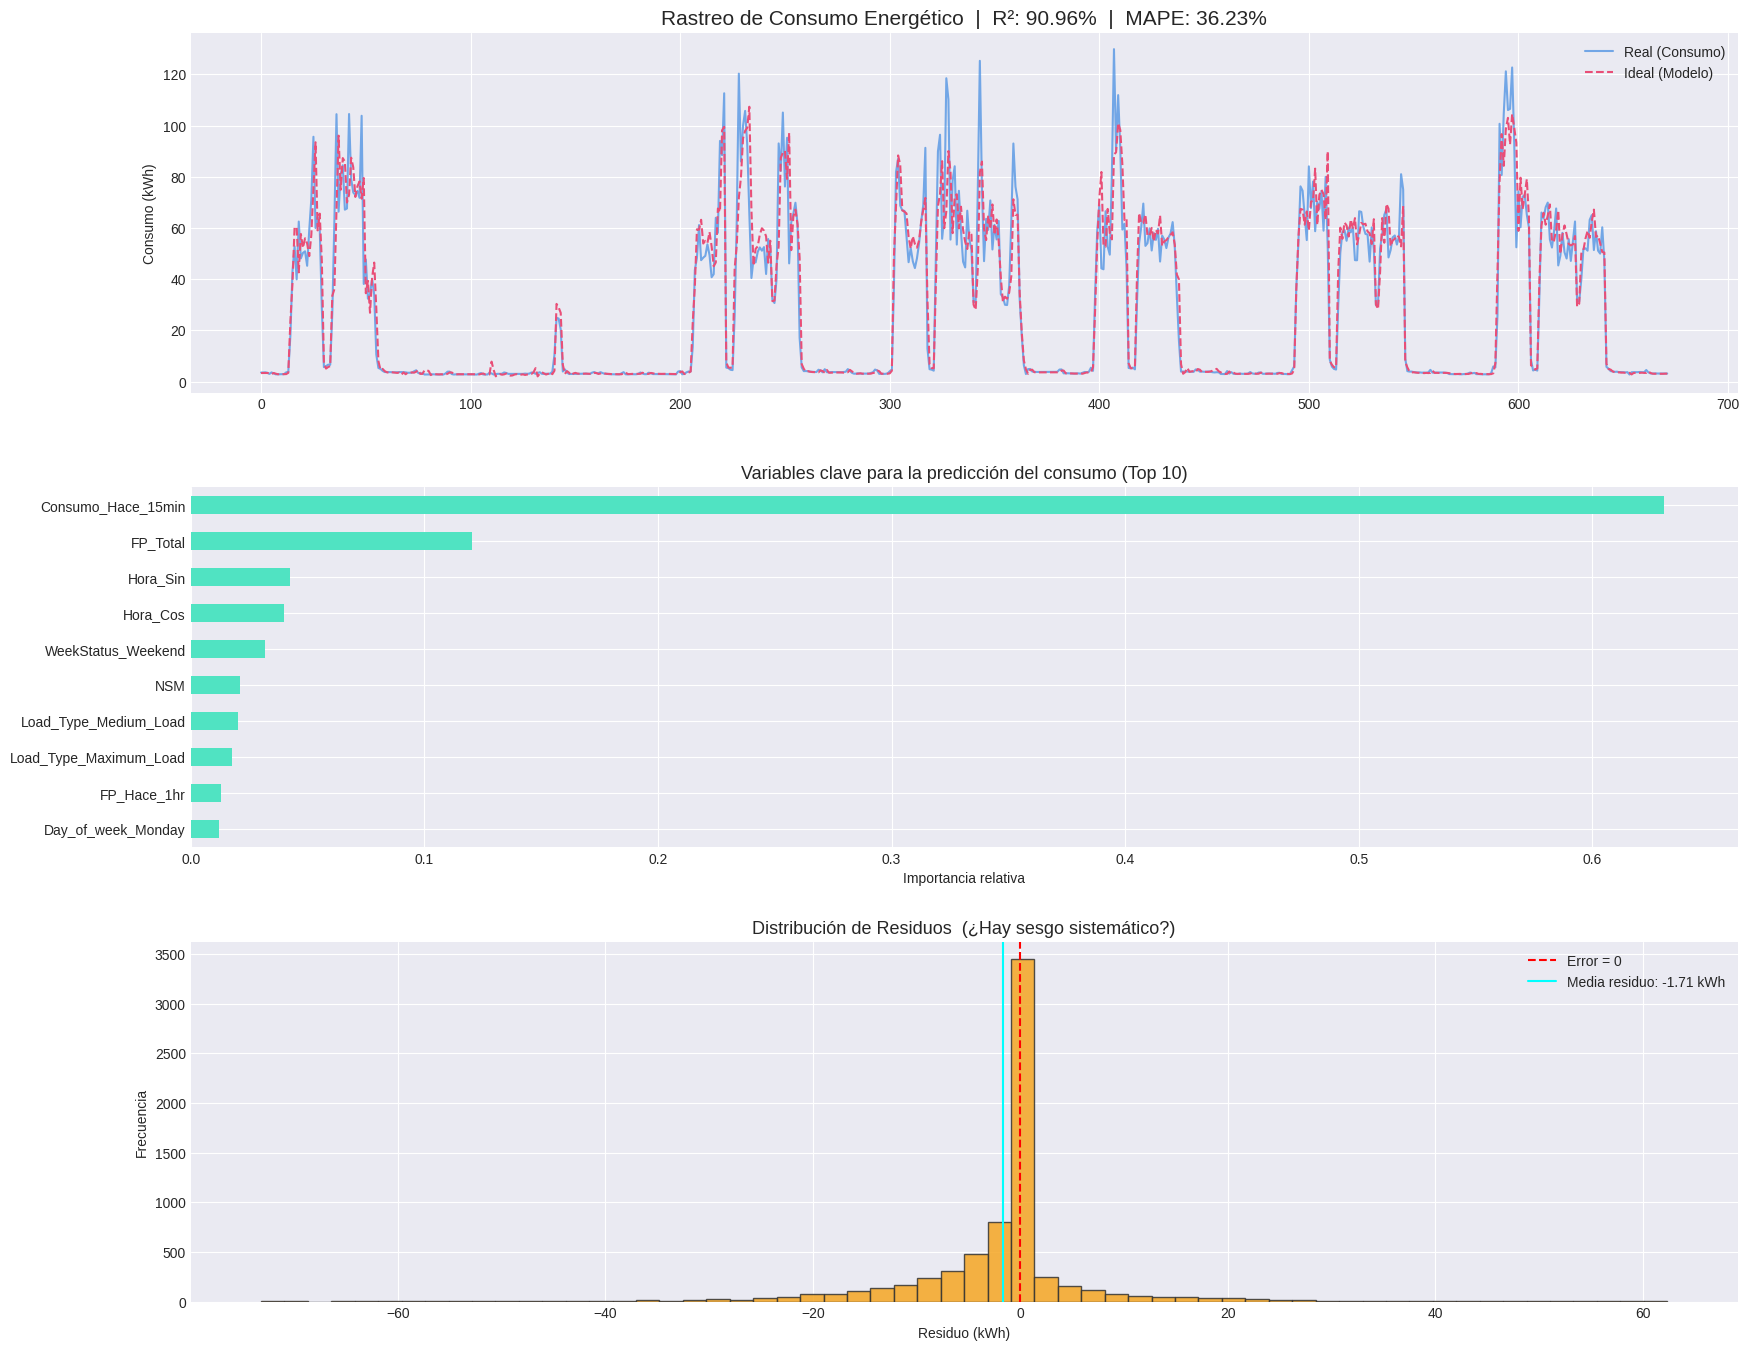

In [55]:
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 14))

# Rastreo de consumo (1 semana ≈ 672 lecturas de 15 min)
ax1 = plt.subplot(3, 1, 1)
ventana = 672
ax1.plot(y_test.values[:ventana], label='Real (Consumo)',  color='#4A90E2', alpha=0.75)
ax1.plot(y_pred[:ventana],        label='Ideal (Modelo)',  color='#E94E77', linestyle='--')
ax1.set_title(
    f'Rastreo de Consumo Energético  |  R²: {score_r2*100:.2f}%  |  MAPE: {mape:.2f}%',
    fontsize=15
)
ax1.set_ylabel('Consumo (kWh)')
ax1.legend()

# Importancia de variables (top 10)
ax2 = plt.subplot(3, 1, 2)
importancias = (
    pd.Series(mejor_modelo.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(10)
)
importancias.plot(kind='barh', color='#50E3C2', ax=ax2)
ax2.set_title('Variables clave para la predicción del consumo (Top 10)', fontsize=13)
ax2.set_xlabel('Importancia relativa')

# Distribución de residuos (diagnóstico de sesgo del modelo)
ax3 = plt.subplot(3, 1, 3)
residuos = y_test.values - y_pred
ax3.hist(residuos, bins=60, color='#F5A623', edgecolor='#333', alpha=0.85)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
ax3.axvline(residuos.mean(), color='cyan', linestyle='-', linewidth=1.5,
            label=f'Media residuo: {residuos.mean():.2f} kWh')
ax3.set_title('Distribución de Residuos  (¿Hay sesgo sistemático?)', fontsize=13)
ax3.set_xlabel('Residuo (kWh)')
ax3.set_ylabel('Frecuencia')
ax3.legend()

plt.tight_layout(pad=2.5)
plt.savefig('reporte_consumo_energetico.png', dpi=150, bbox_inches='tight')
plt.show()


# 8. REPORTE TÉCNICO FINAL


In [59]:
print("\n" + "="*50)
print("       REPORTE DE LOS DATOS OBTENIDOS")
print("="*50)
print(f"  Mejor max_depth       : {search.best_params_['max_depth']}")
print(f"  Mejor learning_rate   : {search.best_params_['learning_rate']}")
print(f"  Mejor n_estimators    : {search.best_params_['n_estimators']}")
print("-"*50)
print(f"  MAE en prueba         : {mae:.2f} kWh")
print(f"  MAPE en prueba        : {mape:.2f} %  (calculado sobre periodos activos > 1 kWh, {n_excluidos_mape} lecturas excluidas)")
print(f"  R² en prueba          : {score_r2*100:.2f} %")
print(f"(PORCENTAJE DE ACIERTO)")
print("-"*50)
print(f"  MAE promedio CV       : {mae_cv_mean:.2f} ± {mae_cv_std:.2f} kWh")
sobreajuste = mae - mae_cv_mean
print(f"  Δ (prueba - CV)       : {sobreajuste:+.2f} kWh  "
      f"{'⚠ Posible sobreajuste' if sobreajuste > mae_cv_mean * 0.2 else '✓ Generalización aceptable'}")
print("-"*50)
print(f"  Umbrales de severidad : Baja >15 | Media >{umbral_medio:.1f} | Alta >{umbral_alto:.1f} kWh")
print(f"  Anomalías detectadas  : {len(anomalias)}")
print(f"    · Alta severidad    : {(anomalias['Severidad']=='Alta').sum()}")
print(f"    · Media severidad   : {(anomalias['Severidad']=='Media').sum()}")
print(f"    · Baja severidad    : {(anomalias['Severidad']=='Baja').sum()}")
print("="*50)

print("\nPrimeras 5 anomalías (para diagnóstico de campo):")
print(
    anomalias[['date', 'Usage_kWh', 'Prediccion_Ideal', 'Desviacion', 'Severidad', 'Load_Type']]
    .head()
    .to_string(index=False)
)



       REPORTE DE LOS DATOS OBTENIDOS
  Mejor max_depth       : 5
  Mejor learning_rate   : 0.05
  Mejor n_estimators    : 500
--------------------------------------------------
  MAE en prueba         : 4.84 kWh
  MAPE en prueba        : 36.23 %  (calculado sobre periodos activos > 1 kWh, 1 lecturas excluidas)
  R² en prueba          : 90.96 %
(PORCENTAJE DE ACIERTO)
--------------------------------------------------
  MAE promedio CV       : 4.92 ± 1.02 kWh
  Δ (prueba - CV)       : -0.08 kWh  ✓ Generalización aceptable
--------------------------------------------------
  Umbrales de severidad : Baja >15 | Media >19.1 | Alta >25.6 kWh
  Anomalías detectadas  : 243
    · Alta severidad    : 83
    · Media severidad   : 80
    · Baja severidad    : 80

Primeras 5 anomalías (para diagnóstico de campo):
               date  Usage_kWh  Prediccion_Ideal  Desviacion Severidad    Load_Type
2018-12-19 17:00:00     125.50         63.147141   62.352859      Alta  Medium_Load
2018-11-22 09:45:0